In [1]:
import pandas, numpy, scipy, re

In [2]:
import sklearn, sklearn.preprocessing, sklearn.decomposition

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

# 0. user-defined variables

In [4]:
input_file = '/Users/adrian/research/bmcbf/073_bologna/results/profiles/DESeq2_TPM_values.tsv'

# 1. read expression

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 17)


,D0BioP1,D0BioP2,D0BioP3,D15Biop1,D15Biop2,D15Biop3,D21Biop1,D21Biop2,D21Biop3,D28Biop1,D28Biop2,D28Biop3,D35Biop1,D35Biop3,D7Biop1,D7Biop2,D7Biop3
ENSG00000000003.15,35.270506,34.364281,0.0,18.780241,32.625123,12.701946,14.807643,16.305683,18.517401,12.776087,15.798625,14.049246,17.202033,15.098156,31.055016,25.912023,36.243732
ENSG00000000005.6,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,61.570654,67.077930,0.0,69.776471,46.260491,29.742924,64.977629,62.887102,79.520231,45.613088,61.473748,42.383602,55.803708,48.034289,63.254581,54.107979,59.887071
ENSG00000000457.14,4.328178,3.834016,0.0,4.633803,0.591956,0.000000,3.445599,3.606671,4.003832,3.773132,2.475307,3.219736,4.057349,1.420088,5.123647,5.652187,4.880143
ENSG00000000460.17,3.468993,1.708372,0.0,1.836215,9.971403,0.000000,2.849139,3.979329,2.446041,3.942822,2.501120,1.349350,7.756164,1.182425,1.937998,3.360438,3.434302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,3.531819,3.293259,0.0,4.768089,10.658803,22.088276,8.227029,1.756875,8.313215,2.122023,6.588649,0.320944,1.069442,0.652978,3.948349,3.006421,3.192741
ENSG00000291300.1,0.041077,0.300109,0.0,0.381504,0.000000,0.000000,0.000000,0.946530,0.000000,0.000000,0.132928,0.776467,0.000000,0.000000,0.197272,0.059421,0.413630


In [6]:
for element in expression.columns:
    print(element)

D0BioP1
D0BioP2
D0BioP3
D15Biop1
D15Biop2
D15Biop3
D21Biop1
D21Biop2
D21Biop3
D28Biop1
D28Biop2
D28Biop3
D35Biop1
D35Biop3
D7Biop1
D7Biop2
D7Biop3


# 3. filter and transform

In [7]:
groups = pandas.Series([re.sub(r'\d+$', '', c) for c in expression.columns],
                       index=expression.columns, name='group')

print(groups.index.to_series().groupby(groups.values).agg(list))   # check grouping

group_medians = expression.T.groupby(groups).median().T            # genes × conditions

substantial_expression = expression[group_medians.max(axis=1) >= 2]
high_expression        = expression[group_medians.max(axis=1) >= 100]
print(substantial_expression.shape, high_expression.shape)

D0BioP        [D0BioP1, D0BioP2, D0BioP3]
D15Biop    [D15Biop1, D15Biop2, D15Biop3]
D21Biop    [D21Biop1, D21Biop2, D21Biop3]
D28Biop    [D28Biop1, D28Biop2, D28Biop3]
D35Biop              [D35Biop1, D35Biop3]
D7Biop        [D7Biop1, D7Biop2, D7Biop3]
dtype: object
(14014, 17) (1633, 17)


In [8]:
group_medians

group,D0BioP,D15Biop,D21Biop,D28Biop,D35Biop,D7Biop
ENSG00000000003.15,34.364281,18.780241,16.305683,14.049246,16.150095,31.055016
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,61.570654,46.260491,64.977629,45.613088,51.918999,59.887071
ENSG00000000457.14,3.834016,0.591956,3.606671,3.219736,2.738719,5.123647
ENSG00000000460.17,1.708372,1.836215,2.849139,2.501120,4.469294,3.360438
...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,3.293259,10.658803,8.227029,2.122023,0.861210,3.192741
ENSG00000291300.1,0.041077,0.000000,0.000000,0.132928,0.000000,0.197272


In [9]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

# 4. visualize substantial expression

In [10]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.56512385 0.10719189]


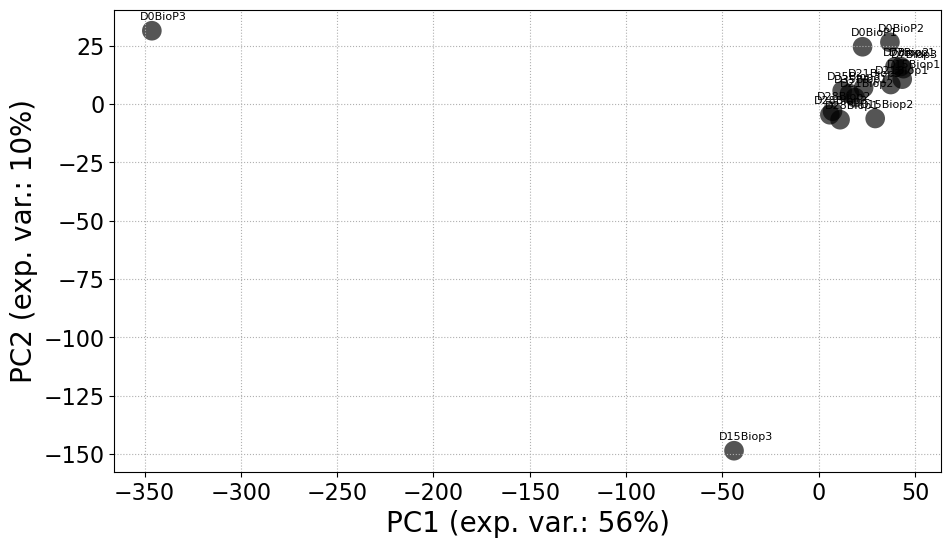

In [11]:
for i in range(len(new)):

    name = pca_substantial_expression.index[i]
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c='black', marker='o', alpha=2/3, edgecolors='none')
    epsilon=6
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

In [12]:
# samples D0BioP3 and D15Biop3 are bad, need to remove them. they were flagged as poor mapping
print(pca_substantial_expression.shape, list(pca_substantial_expression.index))  
pca_substantial_expression = pca_substantial_expression.drop(index=["D0BioP3", "D15Biop3"])
print(pca_substantial_expression.shape, list(pca_substantial_expression.index))  

(17, 14014) ['D0BioP1', 'D0BioP2', 'D0BioP3', 'D15Biop1', 'D15Biop2', 'D15Biop3', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']
(15, 14014) ['D0BioP1', 'D0BioP2', 'D15Biop1', 'D15Biop2', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']


[0.23710762 0.16035098]


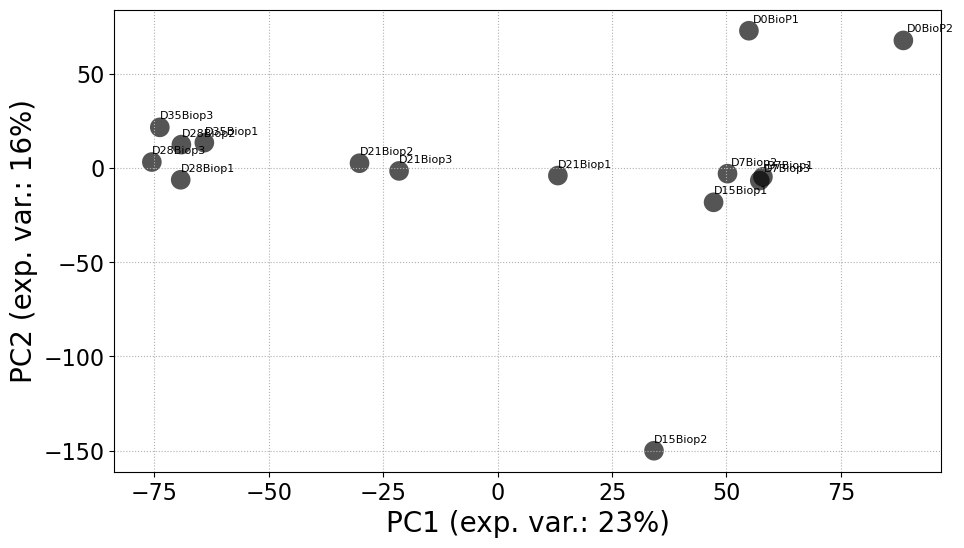

In [13]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

for i in range(len(new)):

    name = pca_substantial_expression.index[i]
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c='black', marker='o', alpha=2/3, edgecolors='none')
    epsilon=6
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

(15, 14014) ['D0BioP1', 'D0BioP2', 'D15Biop1', 'D15Biop2', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']
(14, 14014) ['D0BioP1', 'D0BioP2', 'D15Biop1', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']
[0.26832008 0.14453232]


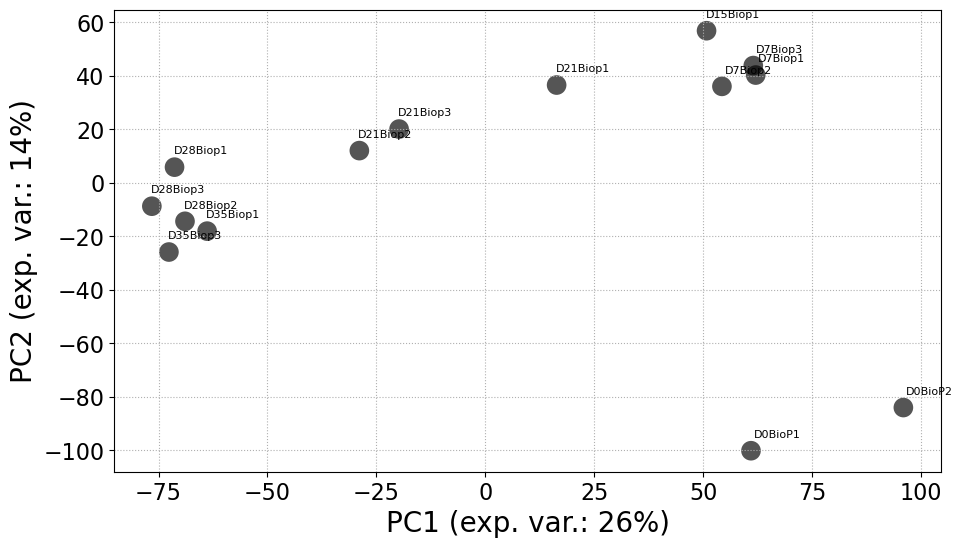

In [14]:
# sample D15Biop2 was also flagged for bad mapping, technical variation.
print(pca_substantial_expression.shape, list(pca_substantial_expression.index))  
pca_substantial_expression = pca_substantial_expression.drop(index=["D15Biop2"])
print(pca_substantial_expression.shape, list(pca_substantial_expression.index)) 

scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

for i in range(len(new)):

    name = pca_substantial_expression.index[i]
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c='black', marker='o', alpha=2/3, edgecolors='none')
    epsilon=6
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

(14, 14014) ['D0BioP1', 'D0BioP2', 'D15Biop1', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']
(13, 14014) ['D0BioP1', 'D0BioP2', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']
[0.27665474 0.14163947]


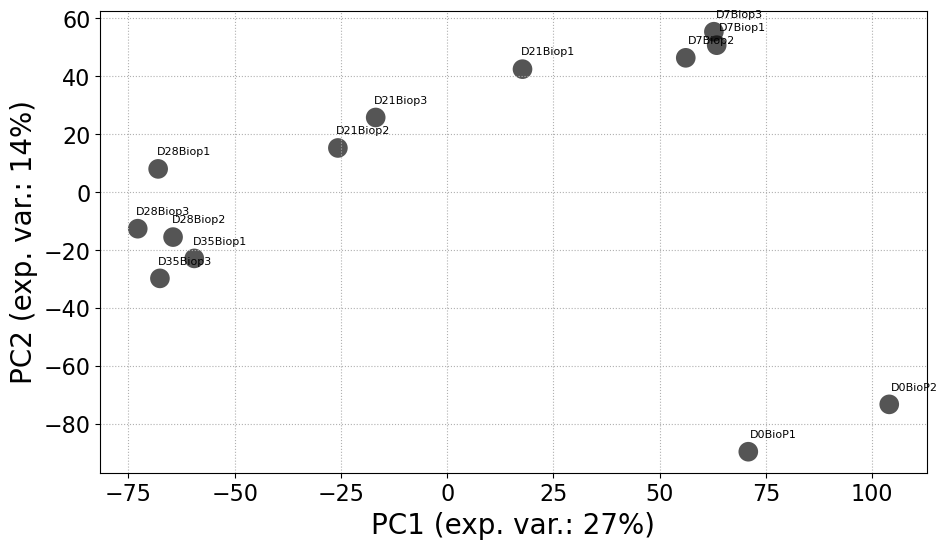

In [15]:
# with only one D15 rep, lets drop this time alltogether, which is close to D7 anyways
print(pca_substantial_expression.shape, list(pca_substantial_expression.index))  
pca_substantial_expression = pca_substantial_expression.drop(index=["D15Biop1"])
print(pca_substantial_expression.shape, list(pca_substantial_expression.index)) 

scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_substantial_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

for i in range(len(new)):

    name = pca_substantial_expression.index[i]
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c='black', marker='o', alpha=2/3, edgecolors='none')
    epsilon=6
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

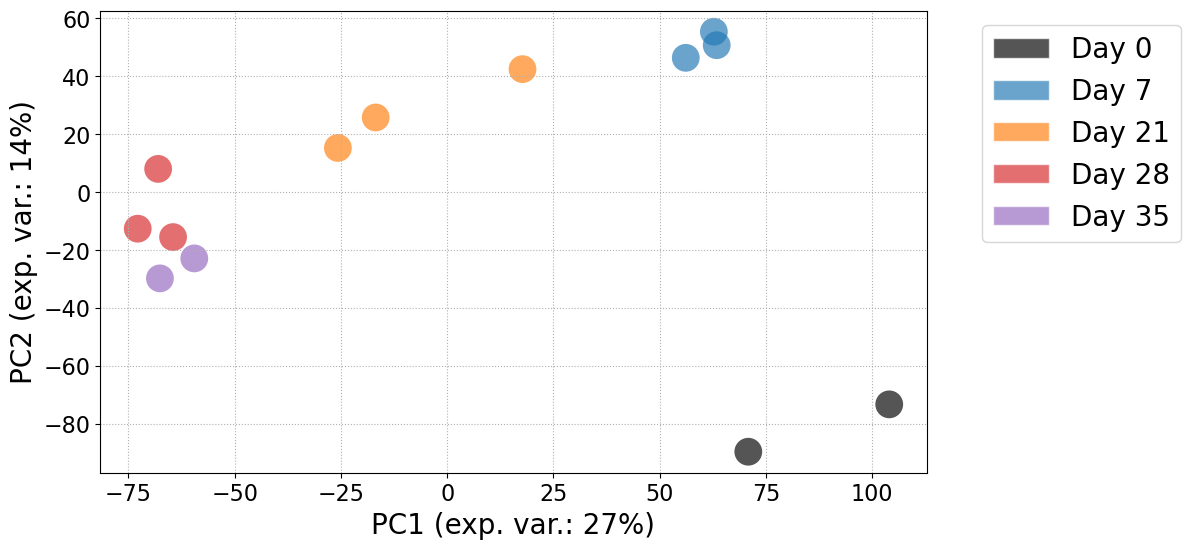

In [16]:
# this is the final comparison. 
# Reliably trust D7-D21, D21-D28. 
# Not so much D0-D7 and D28-35. Technically can be done, but you will be recovering technical variation, not biological.

for i in range(len(new)):

    name = pca_substantial_expression.index[i]

    # colors
    if 'D0' in name:
        the_color = 'black'
    elif 'D7' in name:
        the_color = 'tab:blue'
    elif 'D21' in name:
        the_color = 'tab:orange'
    elif 'D28' in name:
        the_color = 'tab:red'
    elif 'D35' in name:
        the_color = 'tab:purple'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=2/3, edgecolors='none')

legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:purple',    edgecolor='white', alpha=2/3),
]    
matplotlib.pyplot.legend(legend_elements, ['Day 0', 'Day 7', 'Day 21', 'Day 28', 'Day 35'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()

# 4. visualize high expression

In [17]:
print(pca_high_expression.shape, list(pca_high_expression.index))  
pca_high_expression = pca_high_expression.drop(index=["D0BioP3", "D15Biop3", "D15Biop2", "D15Biop1"])
print(pca_high_expression.shape, list(pca_high_expression.index))  

(17, 1633) ['D0BioP1', 'D0BioP2', 'D0BioP3', 'D15Biop1', 'D15Biop2', 'D15Biop3', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']
(13, 1633) ['D0BioP1', 'D0BioP2', 'D21Biop1', 'D21Biop2', 'D21Biop3', 'D28Biop1', 'D28Biop2', 'D28Biop3', 'D35Biop1', 'D35Biop3', 'D7Biop1', 'D7Biop2', 'D7Biop3']


In [18]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.37133372 0.19881062]


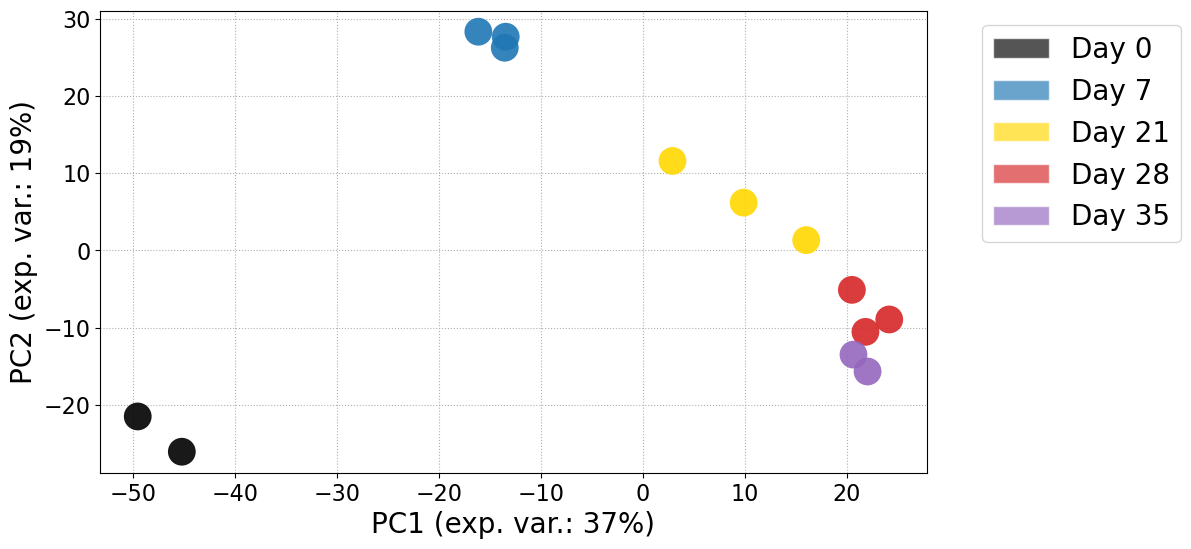

In [24]:
for i in range(len(new)):

    name = pca_high_expression.index[i]

    # colors
    if 'D0' in name:
        the_color = 'black'
    elif 'D7' in name:
        the_color = 'tab:blue'
    elif 'D21' in name:
        the_color = 'gold'
    elif 'D28' in name:
        the_color = 'tab:red'
    elif 'D35' in name:
        the_color = 'tab:purple'
    else:
        print('error')
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=400, c=the_color, marker='o', alpha=9/10, edgecolors='none', zorder=3)

legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='gold',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:purple',    edgecolor='white', alpha=2/3),
]    
matplotlib.pyplot.legend(legend_elements, ['Day 0', 'Day 7', 'Day 21', 'Day 28', 'Day 35'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))

matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':', zorder=0)

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('pca.svg')

# 5. distributions

In [20]:
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

,D0BioP1,D0BioP2,D0BioP3,D15Biop1,D15Biop2,D15Biop3,D21Biop1,D21Biop2,D21Biop3,D28Biop1,D28Biop2,D28Biop3,D35Biop1,D35Biop3,D7Biop1,D7Biop2,D7Biop3
ENSG00000000003.15,5.180725,5.144221,0.0,4.305988,5.071468,3.776309,3.982550,4.113174,4.286689,3.784094,4.070271,3.911619,4.186028,4.008824,5.002478,4.750179,5.218926
ENSG00000000005.6,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,5.967414,6.089115,0.0,6.145198,5.562563,4.942182,6.043905,5.997453,6.331279,5.542663,5.965178,5.439078,5.827913,5.615719,6.005727,5.784189,5.928064
ENSG00000000457.14,2.413642,2.273222,0.0,2.494109,0.670801,0.000000,2.152378,2.203725,2.323033,2.254936,1.797140,2.077153,2.338381,1.275059,2.614391,2.733829,2.555851
ENSG00000000460.17,2.159950,1.437426,0.0,1.503967,3.455676,0.000000,1.944536,2.315951,1.784940,2.305335,1.807816,1.232261,3.130299,1.125932,1.554833,2.124473,2.148707


160
15.97749101508531


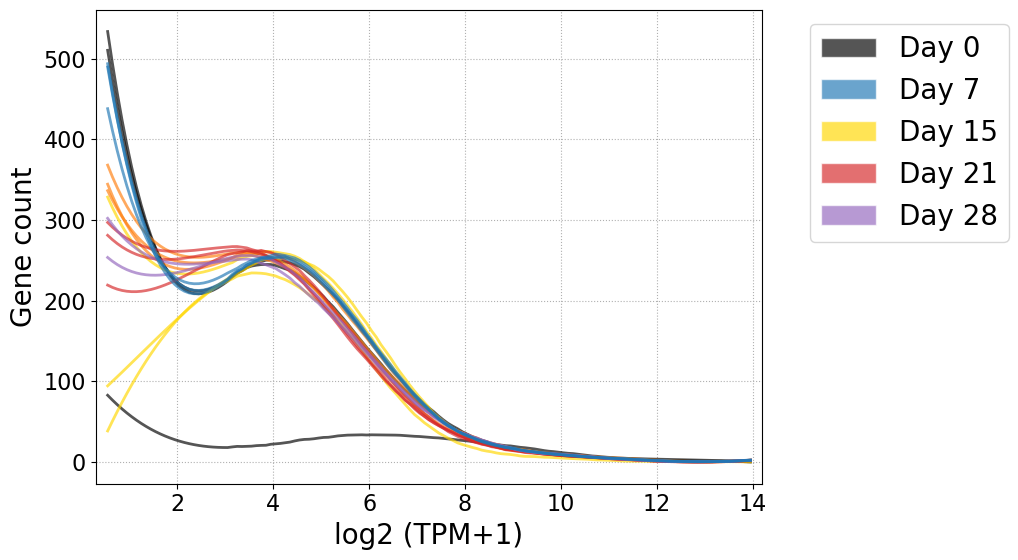

In [21]:
found_max = 16
number_of_bins = int(found_max*10)
print(number_of_bins)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]

    # colors
    if 'D0' in name:
        the_color = 'black'
    elif 'D7' in name:
        the_color = 'tab:blue'
    elif 'D15' in name:
        the_color = 'gold'
    elif 'D21' in name:
        the_color = 'tab:orange'
    elif 'D28' in name:
        the_color = 'tab:red'
    elif 'D35' in name:
        the_color = 'tab:purple'
    else:
        print('error')

    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=2/3, color=the_color)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])

matplotlib.pyplot.legend(legend_elements, ['Day 0', 'Day 7', 'Day 15', 'Day 21', 'Day 28', 'Day 35'], ncol=1, loc='upper left', bbox_to_anchor=(1.05, 1))


legend_elements = [
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='black',      edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:blue',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='gold',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:orange',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:red',    edgecolor='white', alpha=2/3),
    matplotlib.patches.Rectangle((0, 0), 1.8, 1, facecolor='tab:purple',    edgecolor='white', alpha=2/3),
]    

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)